Multi-Layer typically refers to a Multi-Layer Neural Network, also known as a Multi-Layer Perceptron (MLP) in machine learning.

It is a type of artificial neural network that consists of multiple layers of neurons:

Input layer → receives the data

Hidden layer(s) → process and transform the data

Output layer → produces the final prediction

Each layer is connected through weighted links, and the network learns by adjusting these weights to minimize error.

The key advantage of multi-layer networks is their ability to model complex, non-linear relationships, unlike simple models such as linear or logistic regression. This makes them powerful for tasks like classification, regression, image recognition, and pattern detection.

👉 In simple terms:
A multi-layer model learns by passing data through several layers of transformations, gradually extracting deeper patterns at each step.

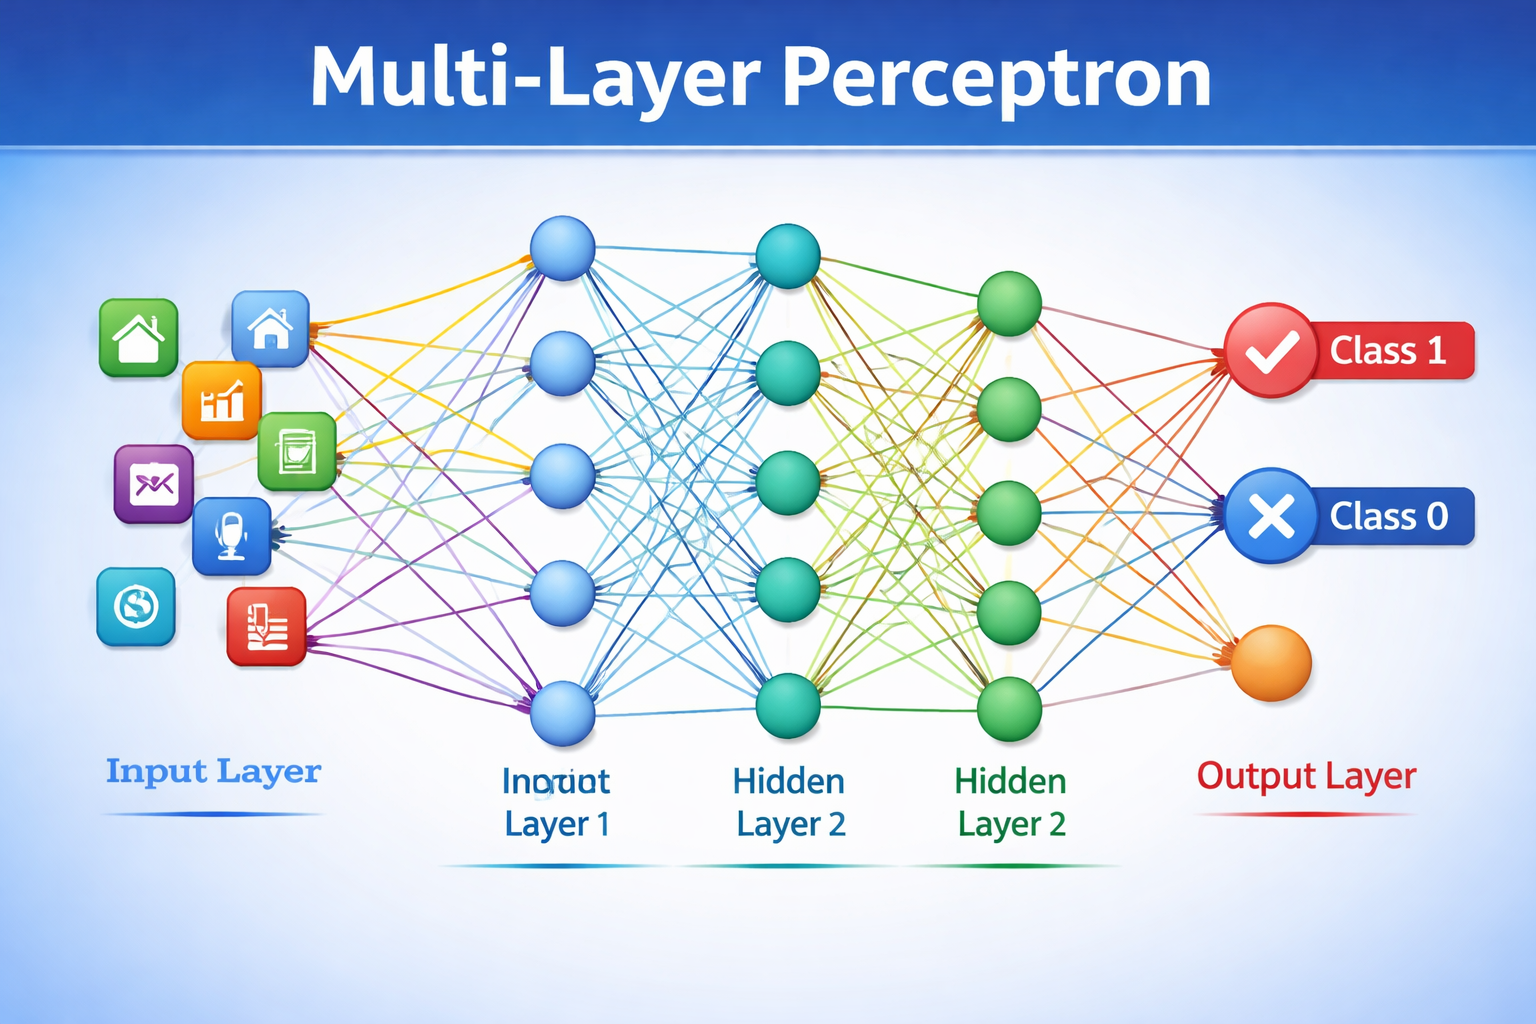

This model is classified as a Multi-Layer Perceptron (MLP) because it utilizes the MLPClassifier with one or more hidden layers (e.g., (50,) or (50, 50)), enabling it to learn complex, non-linear relationships in the data. The architecture consists of an input layer with 13 wine features, followed by one or more fully connected hidden layers using ReLU activation, and an output layer with three neurons for multi-class classification.

The learning process involves a forward pass, where inputs are propagated through the network to compute predictions, followed by backpropagation, where errors are propagated backward to compute gradients. These gradients are then used to update weights using the Adam optimizer, improving model performance iteratively.

Model evaluation and understanding are supported through loss curve visualization to monitor convergence and confusion matrices to analyze class-wise performance. Additionally, hyperparameter tuning such as adjusting hidden layer sizes, regularization (alpha), and learning rate demonstrates how architectural and optimization choices impact accuracy, reinforcing the model’s effectiveness and interpretability.

In [1]:
import numpy as np
import pandas as pd

# Dataset
from sklearn.datasets import load_wine

# Model & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Metrics & plots
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Plot inline
%matplotlib inline

In [3]:
wine = load_wine() #Load Data

X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Show basic info
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nTarget classes:", target_names)

df.head()


Shape of X: (178, 13)
Shape of y: (178,)

Target classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [5]:
class_counts = df['target'].value_counts().sort_index()
for idx, count in class_counts.items():
    print(f"Class {idx} ({target_names[idx]}): {count} samples")


Class 0 (class_0): 59 samples
Class 1 (class_1): 71 samples
Class 2 (class_2): 48 samples


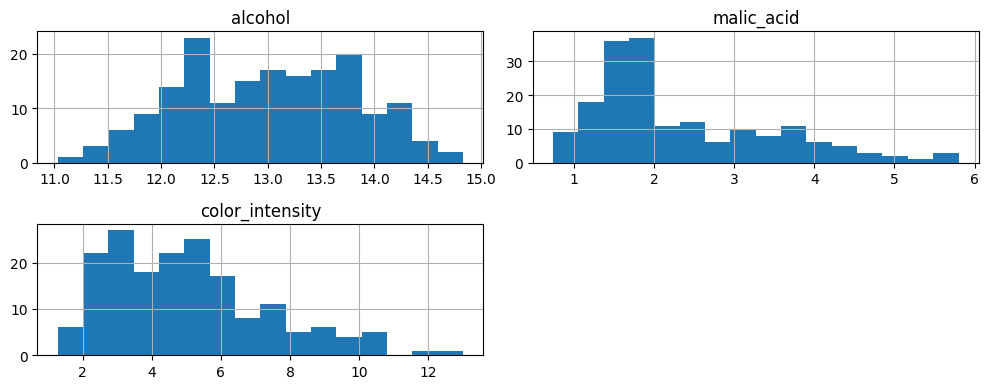

In [6]:
df[['alcohol', 'malic_acid', 'color_intensity']].hist(bins=16, figsize=(10, 4))
plt.tight_layout()
plt.show()

In [8]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 142
Test samples: 36


Baseline MLP Model

A baseline Multi-Layer Perceptron (MLP) model is implemented using a Pipeline to ensure proper preprocessing and training. Since neural networks are sensitive to feature scaling, StandardScaler() is applied to normalize the input features before feeding them into the model. The pipeline then trains an MLPClassifier with a single hidden layer configuration (hidden_layer_sizes = (50,)) using ReLU activation for non-linear transformations. The model is optimized using the Adam solver, with L2 regularization (alpha = 0.0001) to prevent overfitting, and a maximum of 500 iterations to allow sufficient convergence during training.

In [9]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        max_iter=500,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_baseline = baseline_pipeline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline MLP Accuracy on Test Set: {baseline_acc:.3f}")

Baseline MLP Accuracy on Test Set: 0.944


In [10]:
#Model Evaluation
print("Classification Report – Baseline MLP\n")
print(classification_report(y_test, y_pred_baseline, target_names=target_names))


Classification Report – Baseline MLP

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



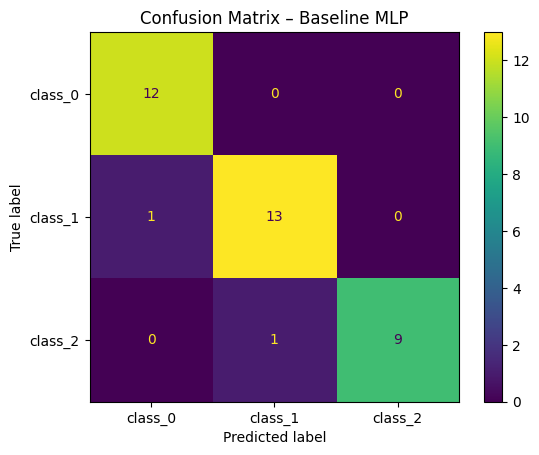

In [11]:
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot()
plt.title("Confusion Matrix – Baseline MLP")
plt.show()


A loss curve is a plot that shows how the model’s error (loss) changes over training iterations (or epochs). It helps track how well a model is learning during training.

The x-axis represents iterations or epochs
The y-axis represents the loss value (error)

👉 In simple terms:
A loss curve shows how the model’s error reduces over time during training, helping you understand if it is learning effectively.

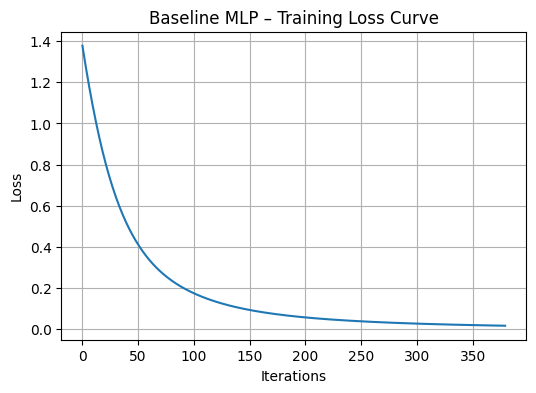

In [12]:
mlp_baseline = baseline_pipeline.named_steps['mlp']

plt.figure(figsize=(6,4))
plt.plot(mlp_baseline.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Baseline MLP – Training Loss Curve")
plt.grid(True)
plt.show()


Hyperparameter Tuning with GridSearchCV

Model performance is enhanced using GridSearchCV, which systematically searches across combinations of hyperparameters to identify the optimal configuration. The tuning process explores variations in network architecture—including different hidden layer sizes such as (50,), (100,), and (50, 50)—as well as regularization strength (alpha) values (0.0001, 0.001, 0.01) and learning rate initialization (learning_rate_init) values (0.001, 0.01).

A 5-fold cross-validation strategy is employed, where the dataset is split into five subsets, and the model is trained and validated multiple times to ensure robust and unbiased performance evaluation. The combination of hyperparameters that yields the best average performance across these folds is selected as the optimal configuration for the model.

In [13]:
mlp_for_grid = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

pipeline_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', mlp_for_grid)
])

param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01]
}

grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search.best_params_)

print(f"\nBest CV Accuracy: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found:
{'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate_init': 0.01}

Best CV Accuracy: 0.993


In [14]:
best_model = grid_search.best_estimator_

y_test_pred_best = best_model.predict(X_test)

best_acc = accuracy_score(y_test, y_test_pred_best)
print(f"Best MLP Accuracy on Test Set: {best_acc:.3f}\n")

print("Classification Report – Best MLP\n")
print(classification_report(y_test, y_test_pred_best, target_names=target_names))


Best MLP Accuracy on Test Set: 0.944

Classification Report – Best MLP

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



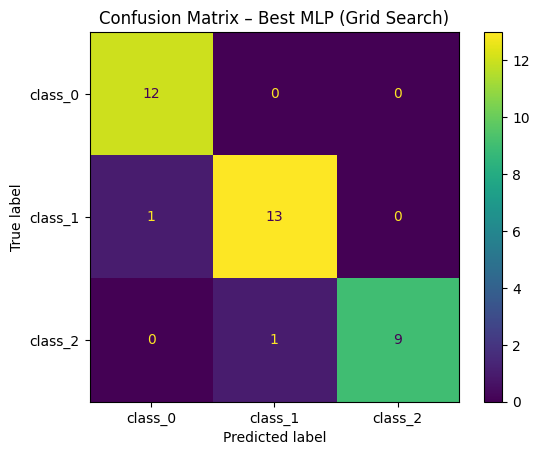

In [15]:
cm_best = confusion_matrix(y_test, y_test_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=target_names)
disp_best.plot()
plt.title("Confusion Matrix – Best MLP (Grid Search)")
plt.show()

In [16]:
#Baseline vs Tuned MLP
print(f"Baseline MLP Test Accuracy: {baseline_acc:.3f}")
print(f"Tuned   MLP Test Accuracy: {best_acc:.3f}")

Baseline MLP Test Accuracy: 0.944
Tuned   MLP Test Accuracy: 0.944


The accuracy remained unchanged after tuning because the baseline MLP was already near-optimal for this relatively simple dataset, and hyperparameter tuning mainly confirmed its effectiveness rather than improving performance.

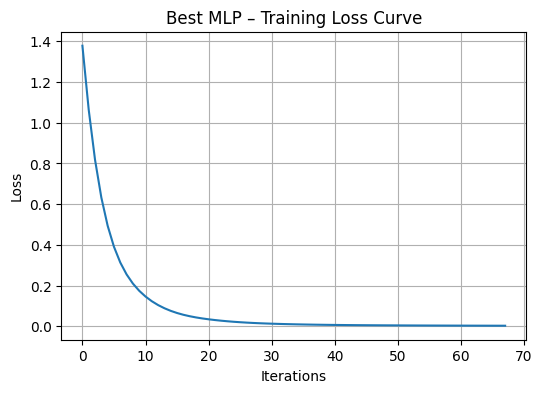

In [17]:
mlp_best = best_model.named_steps['mlp']

plt.figure(figsize=(6,4))
plt.plot(mlp_best.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Best MLP – Training Loss Curve")
plt.grid(True)
plt.show()

Conclusion & Discussion

In this project, an MLP was developed to classify wines using chemical features, covering data preprocessing, training, evaluation, and tuning. The baseline model achieved strong performance (0.944 accuracy), and tuning did not improve accuracy, indicating the baseline was already near-optimal for this dataset. However, tuning provided valuable insights into architecture, regularization, and learning rates. Loss curve analysis showed smooth and stable convergence, with no signs of overfitting or optimization issues.